In [ ]:
from huggingface_hub import DatasetCard


card = DatasetCard.load(root)

card.data['configs']

README.md: 0.00B [00:00, ?B/s]

[{'config_name': 'full_patient_state',
  'data_files': [{'split': 'full_patient_state',
    'path': 'full_patient_state/*.parquet'}]}]

- need to add some sort of death indicator for reward/penalty

In [16]:
df_cohort = pd.read_parquet("data/cohort_df_with_triage_label_corrected.parquet")

Enact a penalty for patients sent to ward then icu that died, and ed ward discharge that died.  Also penalty for ed_discharge_return to icu and ed_discharge died in 72 hrs

Reward for any stable discharge.  reward for direct to icu.  lesser reward for ed_ward_icu

Inference Rules

- ecg and rad can only be ordered once, can be ordered when their results are showing
- same goes for ward transfer
- observe can't be recommended in conjunction with another action
- only observe and vitals can be ordered back to back

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchmetrics.classification import MultilabelF1Score, MultilabelPrecision, MultilabelRecall
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.model_selection import StratifiedShuffleSplit

from datasets import load_dataset

pd.set_option("display.max_columns", 136)

root = "ADS599-Capstone/modeling_data"

df_patient = load_dataset(path=root, name='full_patient_state', split='full_patient_state').to_pandas()

In [3]:
# Keep only timesteps where something changed — drop consecutive observe rows
# This reframes the problem around state changes rather than every clock tick
df_model = df_patient.copy()

# Mark any_action: 1 if any non-observe action occurred at this timestep
non_observe_actions = ["vitals_checked", "labs_ordered", "micro_ordered",
                       "ecg_ordered", "rad_ordered", "dispense_meds", "ward_transfer"]
df_model["any_action"] = df_model[non_observe_actions].any(axis=1).astype(int)

# Flag consecutive observe rows: observe=1 and previous row in same stay was also observe
df_model = df_model.sort_values(["ed_stay_id", "time"]).reset_index(drop=True)
prev_any = df_model.groupby("ed_stay_id")["any_action"].shift(1).fillna(0)
is_consec_observe = (df_model["any_action"] == 0) & (prev_any == 0)

# Keep: rows with any action, plus the first observe row in each consecutive observe block
df_model = df_model[~is_consec_observe].copy()

# Drop ward_transfer — treating escalation/discharge as terminal reward, not action
df_model = df_model.drop(columns=["ward_transfer"])

df_model = df_model.drop(columns=["any_action"]).reset_index(drop=True)

print(f"Original rows: {len(df_patient):,}")
print(f"Filtered rows: {len(df_model):,}")
print(f"Reduction:     {1 - len(df_model)/len(df_patient):.1%}")
print(f"Action rates after filtering:")
action_check = ["observe", "vitals_checked", "labs_ordered", "micro_ordered",
                "ecg_ordered", "rad_ordered", "dispense_meds"]
for a in action_check:
    print(f"  {a:<20} {df_model[a].mean():.4f}")


Original rows: 6,551,723
Filtered rows: 1,237,071
Reduction:     81.1%
Action rates after filtering:
  observe              0.3828
  vitals_checked       0.2782
  labs_ordered         0.2531
  micro_ordered        0.0292
  ecg_ordered          0.0262
  rad_ordered          0.0434
  dispense_meds        0.0824


In [ ]:
df_model.groupby('ed_stay_id').size().sort_values(ascending=False)[:50]

In [4]:
# Consecutive observe rows within a stay
obs = df_patient[['ed_stay_id', 'observe']].copy()
obs['prev_observe'] = obs.groupby('ed_stay_id')['observe'].shift(1)
consecutive = ((obs['observe'] == 1) & (obs['prev_observe'] == 1)).sum()
total_observe = (obs['observe'] == 1).sum()
print(f"Consecutive observe rows: {consecutive:,}")
print(f"Total observe rows:       {total_observe:,}")
print(f"Pct of observe that is consecutive: {consecutive/total_observe:.1%}")

Consecutive observe rows: 5,263,518
Total observe rows:       5,737,095
Pct of observe that is consecutive: 91.7%


# Preprocess and One-Hot-Encode Categorical Columns

In [5]:
# Map Gender
gender_map = {"F": 1, "M": 0}
df_model["gender"] = df_model["gender"].map(gender_map)

# Change acuity to integer
df_model["acuity"] = df_model["acuity"].astype(int)

# Mask height and weight
df_model["height_missing"] = df_model["height"].isna().astype(int)
df_model["weight_missing"] = df_model["weight"].isna().astype(int)
df_model[["height", "weight"]] = df_model[["height", "weight"]].fillna(0)

# Create pain_missing column and convert the Other category to 0
df_model["pain_missing"] = (df_model["current_pain"] == "Other").astype(int)
df_model["current_pain"] = pd.to_numeric(df_model["current_pain"], errors="coerce").fillna(0)

# Mask admission type then one hot encode admission and arrival
df_model["admission_missing"] = df_model["admission_type"].isna().astype(int)
at_dummies = pd.get_dummies(df_model["admission_type"], prefix="admission_type", dummy_na=False, dtype=int)
arrival_dummies = pd.get_dummies(df_model["arrival_transport"], prefix="arrival_transport", dtype=int)
df_model_updated = pd.concat([df_model, at_dummies, arrival_dummies], axis=1).drop(columns=["admission_type", "arrival_transport"])


# Isolate Columns and Fill in Config

In [6]:
# Columns out of order so this pieces all the state cols together
vitals = [c for c in df_model_updated.loc[:, "current_temperature":"dbp_rate"].columns if not c.endswith("_rate") and not c.endswith("_delta")]
med_cols = [c for c in df_model_updated.columns if c.startswith("recon")]
admission_cols = at_dummies.columns.to_list() + ["admission_missing"]
arrival_cols = arrival_dummies.columns.to_list()

# Definitive list of patient state cols
state_cols = df_model_updated.columns[4:71].to_list() + ["gender", "anchor_age", "acuity", "height", "height_missing", "weight_missing", "pain_missing"] + med_cols + vitals + admission_cols + arrival_cols

# Action cols — observe kept, ward_transfer dropped, escalation handled by reward
action_cols = ["observe", "vitals_checked", "labs_ordered", "micro_ordered", "ecg_ordered", "rad_ordered", "dispense_meds"]

# Terminal Cols
terminal_cols = ["discharge", "transfer_icu"]


Not including the rate and delta columns calculated from vitals until we can ensure they were calculated properly.  Too many NaN values in those columns at the moment

In [ ]:
CONFIG = {

    # Data
    "state_cols": state_cols, # list of preprocessed feature column names

    "action_cols": action_cols,  # column name for the action taken

    "reward_col": "terminal_event",  # column name for the observed reward
    
    "next_state_cols":  [],         # column names for the next state
      
    "done_col": ['discharge', 'transfer_icu'], # columns indicating episode termination

    # Action space
    "n_actions": 8,       # number of discrete action e.g. 2 for binary (transfer / don't transfer)

    # Network architecture
    "hidden_layers": [256, 256], # hidden layer sizes for all networks
                                    # BCQ and distributional nets share this
    "activation": "relu", 
    
    # BCQ-specific
    "latent_dim":       32,         # VAE latent space dimensionality
                                    # typically state_dim // 2 is a good start
    "n_candidates":     10,         # number of actions sampled from VAE
                                    # per forward pass at inference
                                    # higher = better coverage, slower inference
    "vae_beta":         0.5,        # KL divergence weight in VAE loss
                                    # higher = more regularized latent space
    "vae_kl_clip":      0.5,        # clamp on VAE latent std to prevent
                                    # posterior collapse during early training
    "perturbation_phi": 0.05,       # max perturbation magnitude applied to
                                    # VAE-sampled actions by the perturbation net
                                    # smaller = stays closer to behavior policy
        # Distributional Q-specific (QR-DQN)
    "n_quantiles":      51,         # number of quantile atoms
                                    # more = finer return distribution
                                    # 51 (C51) and 200 (QR-DQN) are common choices
    "huber_kappa":      1.0,        # Huber loss threshold in quantile regression
                                    # controls transition between L1 and L2 loss

    # Training
    "learning_rate":    1e-4,       # shared learning rate for all optimizers
    "vae_learning_rate":1e-3,       # VAE can tolerate a higher learning rate
                                    # than the Q-network
    "batch_size":       64,
    "n_epochs":         100,
    "gamma":            0.99,       # discount factor
    "tau":              0.005,      # soft target network update rate
                                    # BCQ typically uses smaller tau than CQL
    "grad_clip":        1.0,        # gradient clipping max norm (None to disable)

    # Regularization
    "dropout":          0.0,        # dropout between hidden layers (0 = off)
    "weight_decay":     1e-4,       # L2 regularization on Q-network optimizer

    # Risk preference (distributional)
    "risk_measure":     "mean",     # how to select actions from the distribution
                                    # "mean"  â€” maximize expected return (neutral)
                                    # "cvar"  â€” minimize conditional value at risk
                                    #           (conservative, good for clinical)
                                    # "worst" â€” maximize worst-case quantile
    "cvar_alpha":       0.25,       # CVaR tail fraction (only used if
                                    # risk_measure = "cvar")
                                    # 0.25 = focus on bottom 25% of outcomes

    # Reproducibility
    "seed":             10,

    # Output
    "model_save_path":  "bcq_distributional.pt",
    "log_every_n":      10,
}

# Split Data and Scale Numerical Columns

In [9]:
stay_actions = (
    df_model_updated.groupby("ed_stay_id")[action_cols]
    .max()
    .reset_index()
)

# Train
train_split = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=CONFIG['seed'])
resample_idx, sample_idx = next(train_split.split(stay_actions, stay_actions[action_cols]))
sample_stays = set(stay_actions.iloc[sample_idx]['ed_stay_id'])
df_train = df_model_updated[df_model_updated['ed_stay_id'].isin(sample_stays)].copy()

# Test
stay_test = stay_actions.loc[resample_idx]
test_split = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=CONFIG['seed'])
_, sample_idx = next(test_split.split(stay_test, stay_test[action_cols]))
sample_stays = set(stay_test.iloc[sample_idx]['ed_stay_id'])
df_test = df_model_updated[df_model_updated['ed_stay_id'].isin(sample_stays)].copy()

print(f"Sample stays: {df_train['ed_stay_id'].nunique():,}")
print(df_train.drop_duplicates('ed_stay_id')['terminal_event'].value_counts())
print(f"\nSample stays: {df_test['ed_stay_id'].nunique():,}")
print(df_test.drop_duplicates('ed_stay_id')['terminal_event'].value_counts())

train_idx = set(df_train.index)
test_idx = set(df_test.index)

print(f"\nOverlap: {train_idx.intersection(test_idx)}")

Sample stays: 42,106
terminal_event
DISCHARGE_ED      19072
DISCHARGE_WARD    13917
ICU                9117
Name: count, dtype: int64

Sample stays: 10,527
terminal_event
DISCHARGE_ED      4688
DISCHARGE_WARD    3559
ICU               2280
Name: count, dtype: int64

Overlap: set()


## Scaling

In [10]:
scale = StandardScaler()
scaling_cols = vitals + ['anchor_age', 'weight', 'height', 'time_since_last_hrs']

df_train[scaling_cols] = scale.fit_transform(df_train[scaling_cols])
df_test[scaling_cols] = scale.transform(df_test[scaling_cols])

In [11]:
missing = [c for c in state_cols if c not in df_train.columns]
extra = [c for c in df_train.columns if c not in state_cols + action_cols + ['ed_stay_id', 'subject_id', 'hadm_id', 'time', 'terminal_event', 'ed_boarding']]
print(f"In state_cols but not in df_train: {missing}")
print(f"In df_train but not accounted for: {extra}")

In state_cols but not in df_train: []
In df_train but not accounted for: ['temperature_delta', 'temperature_rate', 'heartrate_delta', 'heartrate_rate', 'resprate_delta', 'resprate_rate', 'o2sat_delta', 'o2sat_rate', 'sbp_delta', 'sbp_rate', 'dbp_delta', 'dbp_rate', 'discharge', 'transfer_icu']


In [12]:
df_train.drop(columns=extra, inplace=True)
df_test.drop(columns=extra, inplace=True)

# Oversample

In [13]:
target_rate = 0.20  # oversample rare actions up to this fraction of training set
oversample_actions = [a for a in action_cols if a != 'observe']

n_base = len(df_train)
extras = []

for action in oversample_actions:
    current_rate = df_train[action].mean()
    if current_rate >= target_rate:
        continue
    minority_rows = df_train[df_train[action] == 1]
    # solve: target_rate = (n_current_pos + n_extra) / (n_base + n_extra)
    n_current_pos = len(minority_rows)
    n_extra = int((target_rate * n_base - n_current_pos) / (1 - target_rate))
    if n_extra <= 0:
        continue
    sampled = minority_rows.sample(n=n_extra, replace=True, random_state=10)
    extras.append(sampled)
    print(f"{action:<20} base rate: {current_rate:.4f}  adding {n_extra:,} rows")

df_train_resampled = pd.concat([df_train] + extras, ignore_index=True)
df_train_resampled = df_train_resampled.sample(frac=1, random_state=10).reset_index(drop=True)

print(f"\nOriginal train rows:   {n_base:,}")
print(f"Resampled train rows:  {len(df_train_resampled):,}")
print("\nNew action rates:")
for a in action_cols:
    print(f"  {a:<20} {df_train_resampled[a].mean():.4f}")

micro_ordered        base rate: 0.0290  adding 131,854 rows
ecg_ordered          base rate: 0.0262  adding 134,037 rows
rad_ordered          base rate: 0.0435  adding 120,697 rows
dispense_meds        base rate: 0.0825  adding 90,630 rows

Original train rows:   617,043
Resampled train rows:  1,094,261

New action rates:
  observe              0.2157
  vitals_checked       0.2636
  labs_ordered         0.2921
  micro_ordered        0.1435
  ecg_ordered          0.1501
  rad_ordered          0.1561
  dispense_meds        0.1704


# Supervisor Network

## Convert To Tensors

In [14]:
torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

# Supervisor network only needs (s, a) â€” no reward, next state, or done
s_train = torch.tensor(df_train[CONFIG["state_cols"]].values.astype(np.float32))
a_train = torch.tensor(df_train[CONFIG["action_cols"]].values.astype(np.float32))

s_test  = torch.tensor(df_test[CONFIG["state_cols"]].values.astype(np.float32))
a_test  = torch.tensor(df_test[CONFIG["action_cols"]].values.astype(np.float32))

train_loader = DataLoader(
    TensorDataset(s_train, a_train),
    batch_size=CONFIG["batch_size"],
    shuffle=True,
)
test_loader = DataLoader(
    TensorDataset(s_test, a_test),
    batch_size=CONFIG["batch_size"],
    shuffle=False,
)

print(f"State dim:  {s_train.shape[1]}")
print(f"Action dim: {a_train.shape[1]}")
print(f"Train rows: {s_train.shape[0]:,}")
print(f"Test rows:  {s_test.shape[0]:,}")

State dim:  124
Action dim: 7
Train rows: 617,043
Test rows:  155,717


## Network

In [28]:
# Need an action label and state feature mapping here

action_mapping = dict(zip(range(0, 10), action_cols))
state_feature_mapping = dict(zip(range(0, len(state_cols)), state_cols))

In [45]:
# true_labels = train_loader.dataset.tensors[1]  # all rows, all 8 actions including observe
# pos_weight = (len(true_labels) - true_labels.sum(axis=0)) / true_labels.sum(axis=0)
# pos_weight = pos_weight.clamp(min=1.0, max=50.0)

MODEL_CONFIG = {
    "batch_size": 64,
    "feature_size": 124,
    "hidden_layers": [256, 256, 128, 128],
    "action_space": 7,  # all actions including observe
    "activation": 'relu',
    "optimizer": torch.optim.Adam,
    "learning_rate": 1e-6,
    "loss_fn": nn.BCEWithLogitsLoss(),
    "epochs": 20,
    "eval": 100,
    "threshold": 0.3
}

In [46]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [47]:
# Build the layer stack from MODEL CONFIG
layers = []
in_size = MODEL_CONFIG['feature_size']

for hs in MODEL_CONFIG['hidden_layers']:
    layers.append(nn.Linear(in_size, hs))
    layers.append(nn.ReLU())
    in_size = hs

layers.append(nn.Linear(in_size, MODEL_CONFIG['action_space']))
linear_stack = nn.Sequential(*layers)

class SuperVisorNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_stack = linear_stack

    def forward(self, x):
        logits = self.linear_stack(x)
        return logits

model = SuperVisorNetwork().to(device)
print(model)

SuperVisorNetwork(
  (linear_stack): Sequential(
    (0): Linear(in_features=124, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=7, bias=True)
  )
)


## Training Loop

In [48]:
f1 = MultilabelF1Score(num_labels=MODEL_CONFIG['action_space'], average='macro')
f1_per_class = MultilabelF1Score(num_labels=MODEL_CONFIG['action_space'], average='none')

In [49]:
optimizer = MODEL_CONFIG['optimizer'](model.parameters(), lr=MODEL_CONFIG['learning_rate'])

In [50]:
def training_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)  # all 8 actions including observe

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        if batch % 1000 == 0:
            loss, current = loss.item(), batch * MODEL_CONFIG['batch_size'] + len(X)
            print(f"loss: {loss:>7.4f} [{current:>5d}/{size:>5d}]")
    return total_loss / len(dataloader)

In [ ]:
def evaluation_loop(dataloader, model, loss_fn):
    num_batches = len(dataloader)
    test_loss = 0
    preds = []
    true_y = dataloader.dataset.tensors[1]

    model.eval()
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()  # all 8 actions including observe
            preds.append(torch.sigmoid(pred))

    final_preds = torch.cat(preds, dim=0)  # (N, 8)

    test_loss /= num_batches
    f1_macro = f1(final_preds, true_y).item()
    f1_per = f1_per_class(final_preds, true_y)
    print(f'\nTest Error: Average Loss: {test_loss:>1.4f}, F1_Macro: {f1_macro:>8.4f}\n')
    for action, score in zip(action_cols, f1_per.tolist()):
        print(f'{action}: {score:.4f}')

    return final_preds, true_y, test_loss

In [52]:
import matplotlib.pyplot as plt

train_losses = []
eval_losses = []

for epoch in range(MODEL_CONFIG['epochs']):
    print(f"\nEpoch {epoch + 1}\n------------------------------")
    t_loss = training_loop(train_loader, model, MODEL_CONFIG['loss_fn'], optimizer)
    train_losses.append(t_loss)
    final_preds, true_labels, e_loss = evaluation_loop(test_loader, model, MODEL_CONFIG['loss_fn'])
    eval_losses.append(e_loss)


Epoch 1
------------------------------
loss:  0.6880 [   64/617043]
loss:  0.6726 [64064/617043]
loss:  0.6560 [128064/617043]
loss:  0.6209 [192064/617043]
loss:  0.5780 [256064/617043]
loss:  0.5148 [320064/617043]
loss:  0.4540 [384064/617043]
loss:  0.4032 [448064/617043]
loss:  0.3683 [512064/617043]
loss:  0.3599 [576064/617043]

Test Error: Average Loss: 0.3718, F1_Macro:   0.0000

observe: 0.0000
vitals_checked: 0.0000
labs_ordered: 0.0000
micro_ordered: 0.0000
ecg_ordered: 0.0000
rad_ordered: 0.0000
dispense_meds: 0.0000

Epoch 2
------------------------------
loss:  0.4313 [   64/617043]
loss:  0.3622 [64064/617043]
loss:  0.3520 [128064/617043]
loss:  0.3485 [192064/617043]
loss:  0.3757 [256064/617043]
loss:  0.3226 [320064/617043]
loss:  0.3524 [384064/617043]
loss:  0.3714 [448064/617043]
loss:  0.3670 [512064/617043]
loss:  0.3336 [576064/617043]

Test Error: Average Loss: 0.3592, F1_Macro:   0.0000

observe: 0.0000
vitals_checked: 0.0000
labs_ordered: 0.0000
micro_orde

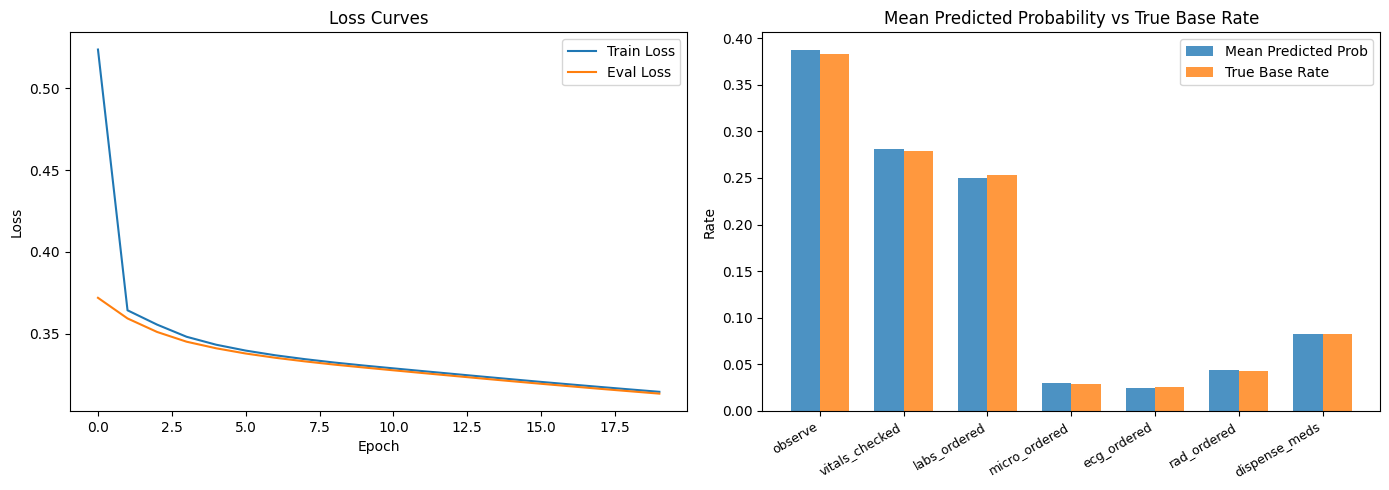

In [58]:
import numpy as np

pred_probs = final_preds.numpy()
true_base  = true_labels.numpy().mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(eval_losses, label="Eval Loss")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

x = np.arange(len(action_cols))
width = 0.35
axes[1].bar(x - width/2, pred_probs.mean(axis=0), width=width, label="Mean Predicted Prob", alpha=0.8)
axes[1].bar(x + width/2, true_base, width=width, label="True Base Rate", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(action_cols, rotation=30, ha='right', fontsize=9)
axes[1].set_title("Mean Predicted Probability vs True Base Rate")
axes[1].set_ylabel("Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

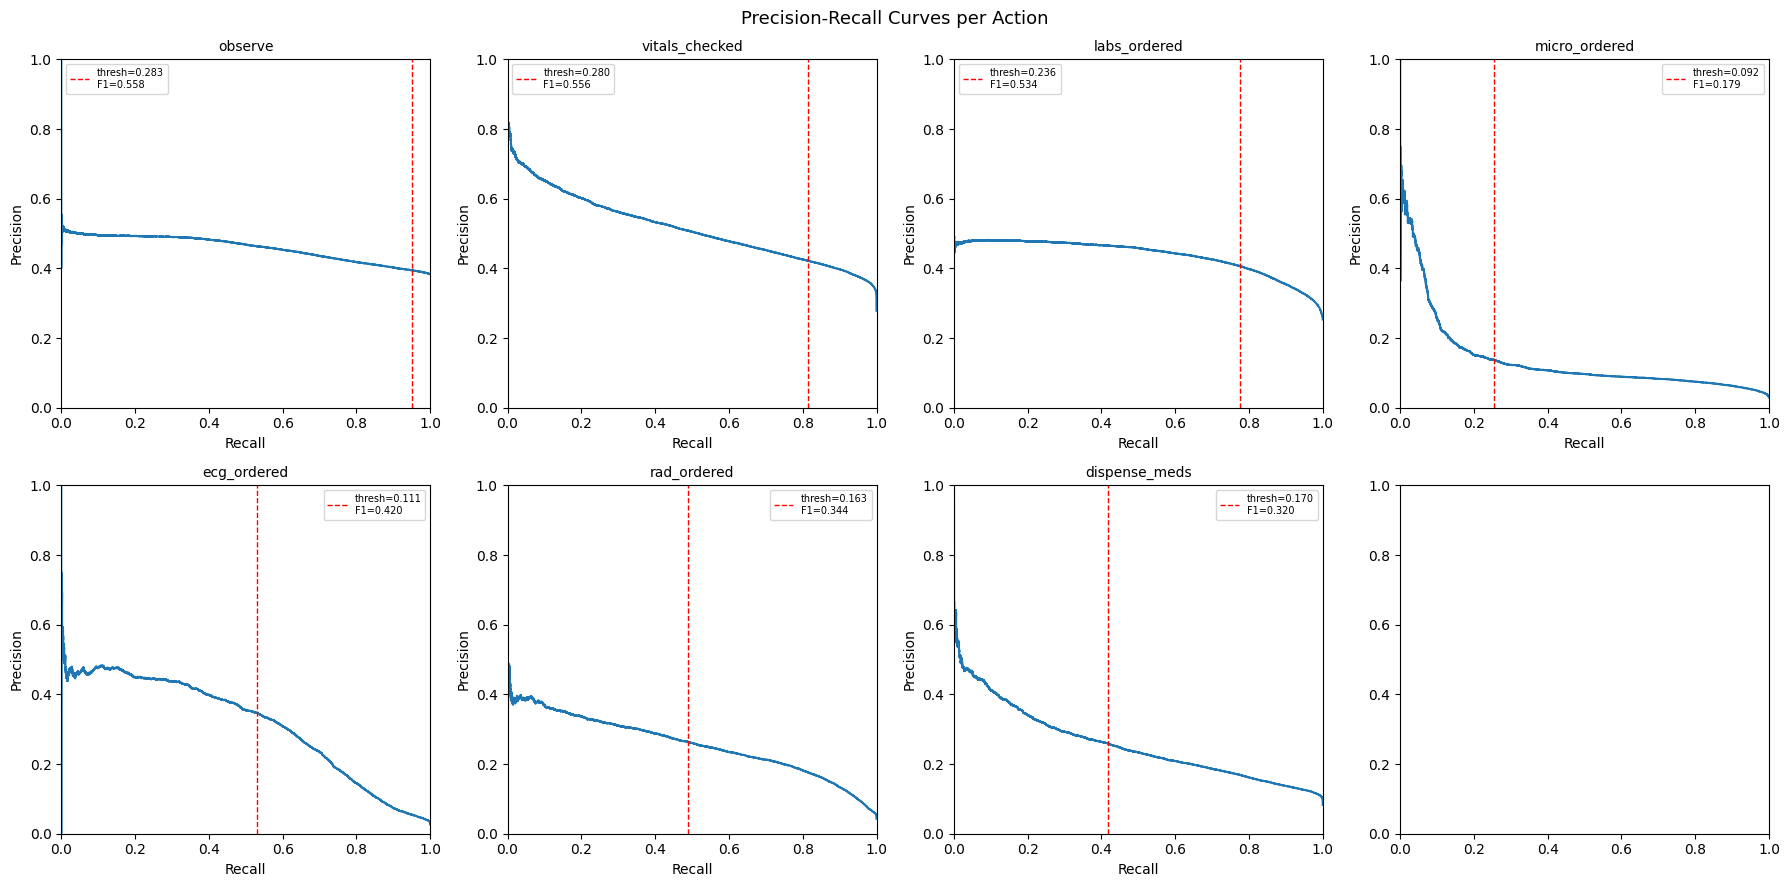


Optimal thresholds (max F1):
  observe              0.2835
  vitals_checked       0.2795
  labs_ordered         0.2355
  micro_ordered        0.0923
  ecg_ordered          0.1109
  rad_ordered          0.1629
  dispense_meds        0.1703


In [59]:
from sklearn.metrics import precision_recall_curve

binary_true = true_labels.numpy().astype(int)
pred_np = final_preds.numpy()

optimal_thresholds = {}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for idx, action in enumerate(action_cols):
    prec, rec, thresh = precision_recall_curve(binary_true[:, idx], pred_np[:, idx])
    f1s = 2 * prec * rec / (prec + rec + 1e-8)
    best_idx = f1s.argmax()
    optimal_thresholds[action] = float(thresh[best_idx])

    axes[idx].plot(rec, prec, lw=1.5)
    axes[idx].axvline(rec[best_idx], color='red', linestyle='--', linewidth=1,
                      label=f"thresh={thresh[best_idx]:.3f}\nF1={f1s[best_idx]:.3f}")
    axes[idx].set_title(action, fontsize=10)
    axes[idx].set_xlabel("Recall")
    axes[idx].set_ylabel("Precision")
    axes[idx].set_xlim(0, 1)
    axes[idx].set_ylim(0, 1)
    axes[idx].legend(fontsize=7)

fig.suptitle("Precision-Recall Curves per Action", fontsize=13)
plt.tight_layout()
plt.show()

print("\nOptimal thresholds (max F1):")
for action, t in optimal_thresholds.items():
    print(f"  {action:<20} {t:.4f}")

observe:     0.0006
vitals_checked:     0.0811
labs_ordered:     0.1580
micro_ordered:     0.9883
ecg_ordered:     0.8213
rad_ordered:     0.6261
dispense_meds:     0.7114


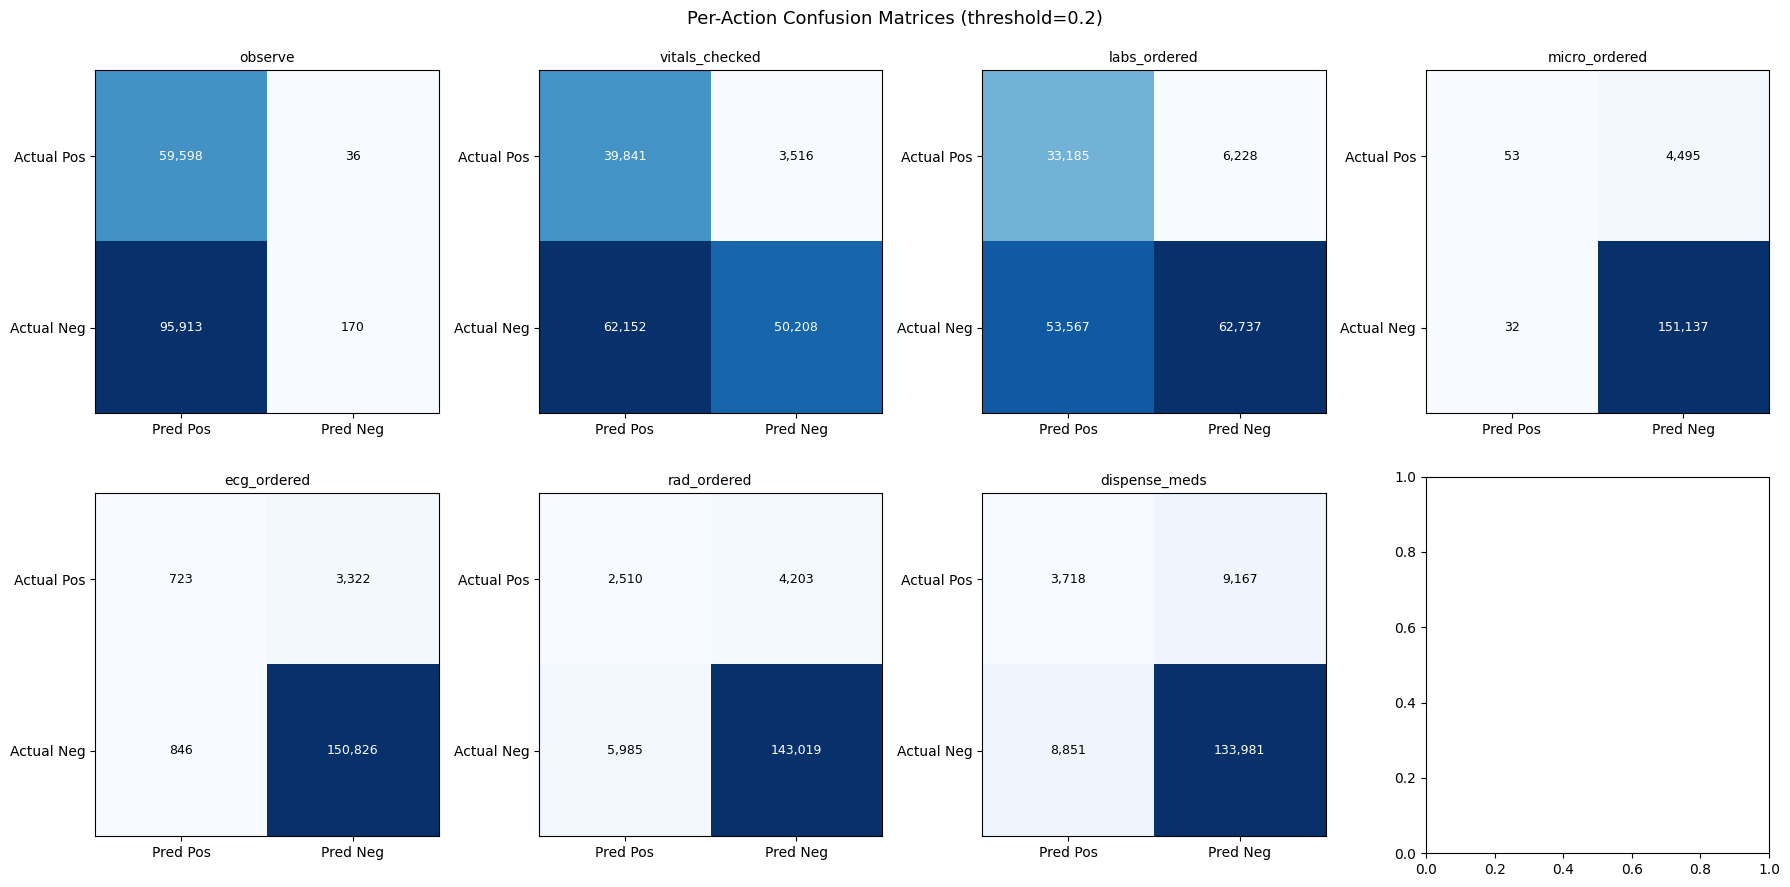

In [60]:
from sklearn.metrics import multilabel_confusion_matrix

binary_preds = (final_preds.numpy() >= 0.2).astype(int)
binary_true  = true_labels.numpy().astype(int)

mcm = multilabel_confusion_matrix(binary_true, binary_preds)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for idx, (action, cm) in enumerate(zip(action_cols, mcm)):
    tn, fp, fn, tp = cm.ravel()
    rate = fn / (fn + tp)
    print(f"{action}: {rate:>10.4f}")
    matrix = np.array([[tp, fn], [fp, tn]])
    axes[idx].imshow(matrix, cmap='Blues')
    axes[idx].set_title(action, fontsize=10)
    axes[idx].set_xticks([0, 1])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(['Pred Pos', 'Pred Neg'])
    axes[idx].set_yticklabels(['Actual Pos', 'Actual Neg'])
    for i, row in enumerate(matrix):
        for j, val in enumerate(row):
            axes[idx].text(j, i, f'{val:,}', ha='center', va='center',
                           color='white' if matrix[i, j] > matrix.max() / 2 else 'black', fontsize=9)

fig.suptitle(f"Per-Action Confusion Matrices (threshold=0.2)", fontsize=13)
plt.tight_layout()
plt.show()

In [56]:
# What % of rows have any non-observe action predicted above threshold?
any_action = (final_preds[1:] > MODEL_CONFIG['threshold']).any(dim=1)
print(f"Rows with any action predicted: {any_action.float().mean():.2%}")

# Per action prediction rate above threshold
for action, rate in zip(action_cols, (final_preds > MODEL_CONFIG['threshold']).float().mean(dim=0).tolist()):
    print(f"{action:<20} {rate:.4%}")


Rows with any action predicted: 99.93%
observe              86.5069%
vitals_checked       50.1705%
labs_ordered         36.2748%
micro_ordered        0.0006%
ecg_ordered          0.0135%
rad_ordered          1.6928%
dispense_meds        1.0102%


In [57]:
(true_labels.sum(axis=0) / len(true_labels)) * 100

tensor([38.2964, 27.8435, 25.3107,  2.9207,  2.5977,  4.3110,  8.2746])